<a href="https://colab.research.google.com/github/Tazin17/pain-intensity-prediction-from-laser-evoked-eeg-responses/blob/main/v5_pipeline_for_exp8_classification_MAIN_FEATURE_EXTRACTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

# Try to unmount if it's already mounted or partially mounted
try:
  drive.flush_and_unmount()
  print('Drive unmounted.')
except ValueError:
  pass # Drive was not mounted, nothing to unmount

# Ensure the mount point is clean
if os.path.isdir('/content/drive'):
  # Remove all contents of the directory, but not the directory itself
  # This avoids issues if the directory is still seen as a mount point
  for item in os.listdir('/content/drive'):
    item_path = os.path.join('/content/drive', item)
    if os.path.isfile(item_path):
      os.remove(item_path)
    elif os.path.isdir(item_path):
      import shutil
      shutil.rmtree(item_path)
  print('Cleared /content/drive directory.')
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)
  print('Created /content/drive directory.')

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)

Drive unmounted.
Created /content/drive directory.
Mounted at /content/drive


In [ ]:
!pip -q install pymatreader mne scipy scikit-learn pandas numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
# CELL 2 — Imports and paths

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pymatreader import read_mat
from scipy.signal import welch
from scipy.stats import skew, kurtosis

EXP_NAME = "EXP8"

# Change this path if your Exp8 folder name is different
EXP8_ROOT = "/content/drive/MyDrive/my dataset_raw_main_exp8"

OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
os.makedirs(OUT_DIR, exist_ok=True)

print("EXP8_ROOT exists:", os.path.exists(EXP8_ROOT))
print("OUT_DIR:", OUT_DIR)

EXP8_ROOT exists: True
OUT_DIR: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH


In [ ]:
# CELL 3 — Find Exp8 rerefer .set files

candidate_dirs = [
    "/content/exp8_rerefer",
    os.path.join(EXP8_ROOT, "derivatives", "rerefer"),
    os.path.join(EXP8_ROOT, "derivatives-rerefer"),
    os.path.join(EXP8_ROOT, "rerefer"),
]

REREFER_DIR = None
set_files = []

for d in candidate_dirs:
    files = sorted(glob.glob(os.path.join(d, "*.set")))
    if len(files) > 0:
        REREFER_DIR = d
        set_files = files
        break

if len(set_files) == 0 and os.path.exists(EXP8_ROOT):
    all_set_files = sorted(glob.glob(os.path.join(EXP8_ROOT, "**", "*.set"), recursive=True))
    rerefer_files = [f for f in all_set_files if "rerefer" in f.lower()]
    set_files = sorted(rerefer_files if len(rerefer_files) > 0 else all_set_files)
    if len(set_files) > 0:
        REREFER_DIR = os.path.dirname(set_files[0])

print("REREFER_DIR:", REREFER_DIR)
print("Number of .set files:", len(set_files))

if len(set_files) == 0:
    raise FileNotFoundError("No Exp8 .set files found. Check EXP8_ROOT.")

print("First 5 files:")
for f in set_files[:5]:
    print(f)

REREFER_DIR: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer
Number of .set files: 223
First 5 files:
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-002_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-003_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-004_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-005_223ByBP.set


In [ ]:
# CELL 4 — Helper functions

def safe_scalar(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        return safe_scalar(x.flatten()[0])
    if isinstance(x, list):
        if len(x) == 0:
            return np.nan
        return safe_scalar(x[0])
    return x

def get_subject_id(path):
    return os.path.basename(path).split("_")[0]

def clean_channel_name(ch):
    return str(ch).replace(" ", "").replace("-", "").replace(".", "").replace("'", "").replace('"', "")

def get_channel_labels(chanlocs, nbchan=None):
    labels = []

    if isinstance(chanlocs, dict) and "labels" in chanlocs:
        labels = [str(x) for x in chanlocs["labels"]]

    elif isinstance(chanlocs, list):
        for ch in chanlocs:
            if isinstance(ch, dict) and "labels" in ch:
                labels.append(str(safe_scalar(ch["labels"])))

    labels = [clean_channel_name(x) for x in labels if str(x).strip() != ""]

    if nbchan is not None and len(labels) != nbchan:
        labels = [f"Ch{i+1:03d}" for i in range(nbchan)]

    return labels

def listify(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return list(x.flatten())
    return [x]

def get_times_ms(mat):
    if "times" in mat:
        times = np.array(mat["times"], dtype=float).flatten()
        if np.nanmax(np.abs(times)) < 20:
            times = times * 1000
        return times

    pnts = int(safe_scalar(mat["pnts"]))
    xmin = float(safe_scalar(mat.get("xmin", -1)))
    xmax = float(safe_scalar(mat.get("xmax", 2)))
    return np.linspace(xmin * 1000, xmax * 1000, pnts)

def load_eeg_data_from_set(mat, set_path, rerefer_dir):
    data = mat["data"]

    if isinstance(data, str):
        datfile = str(safe_scalar(mat.get("datfile", "")))

        if datfile == "" or datfile.lower() == "nan":
            datfile = os.path.splitext(os.path.basename(set_path))[0] + ".fdt"

        fdt_path = os.path.join(rerefer_dir, datfile)

        if not os.path.exists(fdt_path):
            fdt_path = os.path.join(os.path.dirname(set_path), datfile)

        if not os.path.exists(fdt_path):
            raise FileNotFoundError(f"Missing .fdt file: {fdt_path}")

        nbchan = int(safe_scalar(mat["nbchan"]))
        pnts = int(safe_scalar(mat["pnts"]))
        trials = int(safe_scalar(mat["trials"]))

        raw = np.fromfile(fdt_path, dtype=np.float32)
        data = raw.reshape((nbchan, pnts, trials), order="F")

    else:
        data = np.array(data)

    if data.ndim == 2:
        nbchan = int(safe_scalar(mat["nbchan"]))
        pnts = int(safe_scalar(mat["pnts"]))
        trials = int(safe_scalar(mat["trials"]))
        data = data.reshape((nbchan, pnts, trials), order="F")

    return data

def extract_trial_metadata_from_epoch(mat, n_trials):
    pain = [np.nan] * n_trials
    laser = [np.nan] * n_trials
    etype = [np.nan] * n_trials

    epoch = mat.get("epoch", None)

    pain_keys = ["eventrating", "rating", "painrating", "eventpainrating", "eventNRS", "NRS"]
    laser_keys = ["eventlaser_power", "laser_power", "laserpower", "eventlaserpower", "eventLaserPower"]
    type_keys = ["eventtype", "type"]

    if isinstance(epoch, list):
        for i in range(min(len(epoch), n_trials)):
            ep = epoch[i]
            if isinstance(ep, dict):
                for key in pain_keys:
                    if key in ep:
                        pain[i] = safe_scalar(ep[key])
                        break
                for key in laser_keys:
                    if key in ep:
                        laser[i] = safe_scalar(ep[key])
                        break
                for key in type_keys:
                    if key in ep:
                        etype[i] = safe_scalar(ep[key])
                        break

    elif isinstance(epoch, dict):
        for key in pain_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    pain[i] = safe_scalar(vals[i])
                break

        for key in laser_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    laser[i] = safe_scalar(vals[i])
                break

        for key in type_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    etype[i] = safe_scalar(vals[i])
                break

    return pain, laser, etype

In [ ]:
# CELL 5 — Inspect all .set files: subjects, channels, epochs

inventory_rows = []
failed_rows = []

for set_path in tqdm(set_files, desc="Inspecting .set files"):
    sid = get_subject_id(set_path)

    try:
        mat = read_mat(set_path)

        inventory_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "nbchan": int(safe_scalar(mat.get("nbchan", np.nan))),
            "pnts": int(safe_scalar(mat.get("pnts", np.nan))),
            "trials_epochs": int(safe_scalar(mat.get("trials", np.nan))),
            "srate": float(safe_scalar(mat.get("srate", np.nan))),
            "xmin_sec": float(safe_scalar(mat.get("xmin", np.nan))),
            "xmax_sec": float(safe_scalar(mat.get("xmax", np.nan))),
        })

    except Exception as e:
        failed_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "error": str(e)
        })

inventory_df = pd.DataFrame(inventory_rows)
failed_df = pd.DataFrame(failed_rows)

inventory_path = os.path.join(OUT_DIR, "exp8_inventory_epoch_counts.csv")
failed_path = os.path.join(OUT_DIR, "exp8_inventory_failed_files.csv")

inventory_df.to_csv(inventory_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Subjects/files inspected:", len(inventory_df))
print("Failed files:", len(failed_df))

print("\nTrial/epoch count distribution:")
display(inventory_df["trials_epochs"].value_counts().sort_index())

print("\nTotal retained epochs after preprocessing:")
print(int(inventory_df["trials_epochs"].sum()))

print("\nTheoretical maximum:")
print("223 subjects × 30 trials = 6690 epochs")

display(inventory_df.head())

Inspecting .set files: 100%|██████████| 223/223 [00:46<00:00,  4.82it/s]


Subjects/files inspected: 223
Failed files: 0

Trial/epoch count distribution:


,count
trials_epochs,
19,2
20,1
21,3
22,1
23,5
24,9
25,12
26,15
27,16



Total retained epochs after preprocessing:
6275

Theoretical maximum:
223 subjects × 30 trials = 6690 epochs


,subject_id,file,nbchan,pnts,trials_epochs,srate,xmin_sec,xmax_sec
0,sub-001,sub-001_223ByBP.set,64,3000,28,1000.0,-1.0,1.999
1,sub-002,sub-002_223ByBP.set,64,3000,25,1000.0,-1.0,1.999
2,sub-003,sub-003_223ByBP.set,62,3000,25,1000.0,-1.0,1.999
3,sub-004,sub-004_223ByBP.set,64,3000,27,1000.0,-1.0,1.999
4,sub-005,sub-005_223ByBP.set,64,3000,27,1000.0,-1.0,1.999


In [ ]:
# CELL 6 — Inspect one subject deeply

example_path = set_files[0]
mat = read_mat(example_path)

print("Example file:", example_path)

print("\nBasic shape info:")
for k in ["nbchan", "pnts", "trials", "srate", "xmin", "xmax"]:
    print(k, ":", safe_scalar(mat.get(k, None)))

nbchan = int(safe_scalar(mat["nbchan"]))
labels = get_channel_labels(mat.get("chanlocs", []), nbchan=nbchan)

print("\nNumber of channel labels:", len(labels))
print("First 30 channel labels:")
print(labels[:30])

print("\nEpoch object type:", type(mat.get("epoch", None)))

epoch = mat.get("epoch", None)

if isinstance(epoch, list) and len(epoch) > 0:
    print("\nFirst epoch keys:")
    print(epoch[0].keys() if isinstance(epoch[0], dict) else type(epoch[0]))

elif isinstance(epoch, dict):
    print("\nEpoch dictionary keys:")
    print(epoch.keys())

Example file: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set

Basic shape info:
nbchan : 64
pnts : 3000
trials : 28
srate : 1000
xmin : -1
xmax : 1.999

Number of channel labels: 64
First 30 channel labels:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'FT9', 'FT10']

Epoch object type: <class 'dict'>

Epoch dictionary keys:
dict_keys(['event', 'eventlatency', 'eventduration', 'eventchannel', 'eventbvtime', 'eventbvmknum', 'eventvisible', 'eventtype', 'eventcode', 'eventurevent', 'eventrating', 'eventlaser_power'])


In [ ]:
import pandas as pd

csv_path = (
    "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "exp8_trial_metadata_with_binary_labels.csv"
)

meta_df = pd.read_csv(csv_path)

print("CSV loaded successfully.")
print("Shape:", meta_df.shape)
print("Subjects:", meta_df["subject_id"].nunique())
print("Total trials/epochs:", len(meta_df))

print("\nFirst 10 rows:")
display(meta_df.head(10))

print("\nColumns:")
print(meta_df.columns.tolist())

print("\nPain-rating distribution:")
display(
    meta_df["painrating"]
    .value_counts()
    .sort_index()
    .rename("count")
)

print("\nBinary class distribution:")
display(
    meta_df["pain_class"]
    .value_counts()
    .rename("count")
)

CSV loaded successfully.
Shape: (6275, 9)
Subjects: 223
Total trials/epochs: 6275

First 10 rows:


,experiment,subject_id,trial_num,painrating,laser_power,event_type,source_file,pain_label,pain_class
0,EXP8,sub-001,1,0,3.5,S 32,sub-001_223ByBP.set,0,low_pain
1,EXP8,sub-001,2,5,4.0,S 33,sub-001_223ByBP.set,1,high_pain
2,EXP8,sub-001,3,5,4.0,S 33,sub-001_223ByBP.set,1,high_pain
3,EXP8,sub-001,4,3,3.5,S 32,sub-001_223ByBP.set,0,low_pain
4,EXP8,sub-001,5,4,3.5,S 32,sub-001_223ByBP.set,0,low_pain
5,EXP8,sub-001,6,5,3.5,S 32,sub-001_223ByBP.set,1,high_pain
6,EXP8,sub-001,7,5,3.5,S 32,sub-001_223ByBP.set,1,high_pain
7,EXP8,sub-001,8,6,4.0,S 33,sub-001_223ByBP.set,1,high_pain
8,EXP8,sub-001,9,4,3.5,S 32,sub-001_223ByBP.set,0,low_pain
9,EXP8,sub-001,10,5,4.0,S 33,sub-001_223ByBP.set,1,high_pain



Columns:
['experiment', 'subject_id', 'trial_num', 'painrating', 'laser_power', 'event_type', 'source_file', 'pain_label', 'pain_class']

Pain-rating distribution:


,count
painrating,
0,51
1,207
2,438
3,855
4,1174
5,1012
6,808
7,751
8,502



Binary class distribution:


,count
pain_class,
high_pain,3550
low_pain,2725


In [ ]:
# CELL 8 — Subject-wise label balance

subject_label_summary = meta_df.groupby("subject_id").agg(
    n_trials=("painrating", "count"),
    pain_min=("painrating", "min"),
    pain_max=("painrating", "max"),
    pain_mean=("painrating", "mean"),
    low_count=("pain_label", lambda x: int((x == 0).sum())),
    high_count=("pain_label", lambda x: int((x == 1).sum())),
).reset_index()

subject_label_summary["has_both_classes"] = (
    (subject_label_summary["low_count"] > 0) &
    (subject_label_summary["high_count"] > 0)
)

summary_path = os.path.join(OUT_DIR, "exp8_subject_label_balance.csv")
subject_label_summary.to_csv(summary_path, index=False)

print("Total subjects:", subject_label_summary.shape[0])
print("Subjects with both classes:", subject_label_summary["has_both_classes"].sum())
print("Subjects with only one class:", (~subject_label_summary["has_both_classes"]).sum())

print("\nTrial count distribution:")
display(subject_label_summary["n_trials"].value_counts().sort_index())

display(subject_label_summary.head(20))

Total subjects: 223
Subjects with both classes: 205
Subjects with only one class: 18

Trial count distribution:


,count
n_trials,
19,2
20,1
21,3
22,1
23,5
24,9
25,12
26,15
27,16


,subject_id,n_trials,pain_min,pain_max,pain_mean,low_count,high_count,has_both_classes
0,sub-001,28,0,7,4.571429,11,17,True
1,sub-002,25,0,6,1.960000,23,2,True
2,sub-003,25,1,9,3.640000,18,7,True
3,sub-004,27,2,8,5.518519,6,21,True
4,sub-005,27,3,6,4.518519,13,14,True
5,sub-006,30,2,6,3.866667,22,8,True
6,sub-007,28,0,7,4.714286,10,18,True
7,sub-008,30,1,6,3.266667,24,6,True
8,sub-009,27,1,6,3.074074,24,3,True
9,sub-010,26,4,9,6.384615,3,23,True


Saved: figure_1_nrs_pain_rating_distribution.png, figure_1_nrs_pain_rating_distribution.pdf and figure_1_nrs_pain_rating_distribution.svg


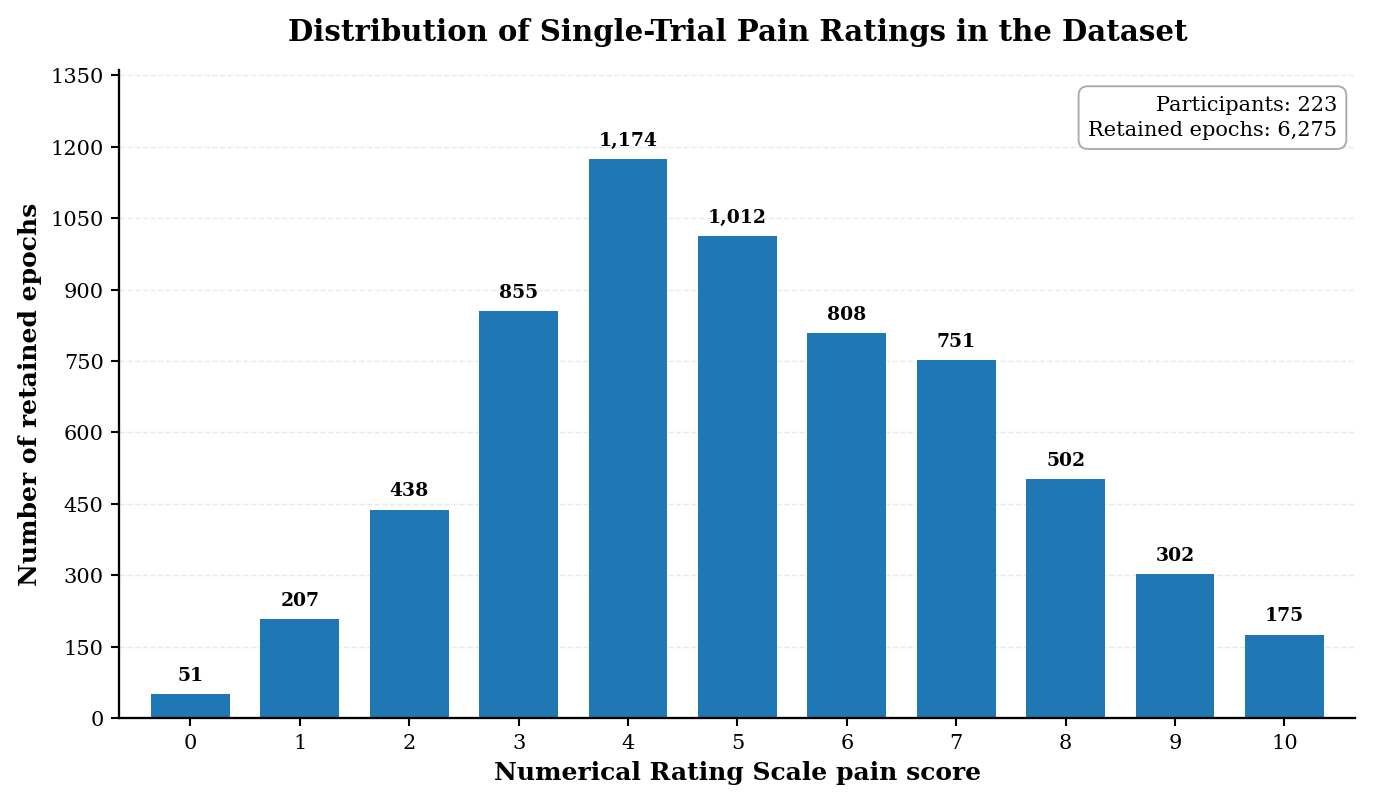

Saved: figure_2_binary_pain_class_distribution.png, figure_2_binary_pain_class_distribution.pdf and figure_2_binary_pain_class_distribution.svg


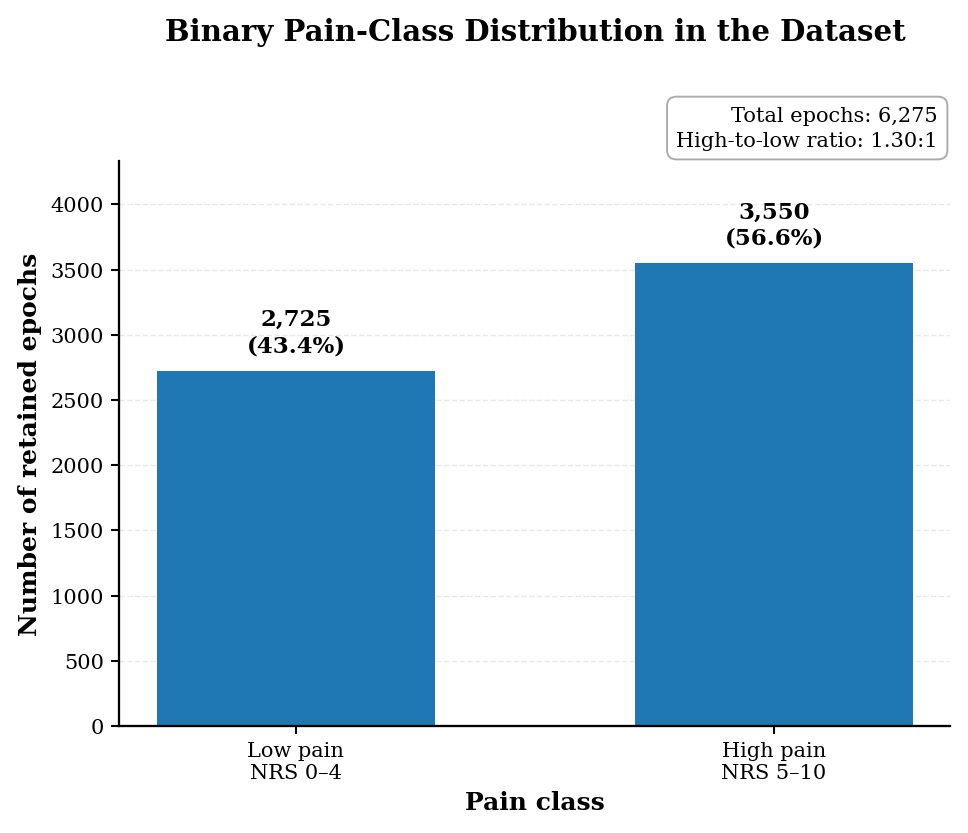

Saved: figure_3_retained_epochs_per_participant.png, figure_3_retained_epochs_per_participant.pdf and figure_3_retained_epochs_per_participant.svg


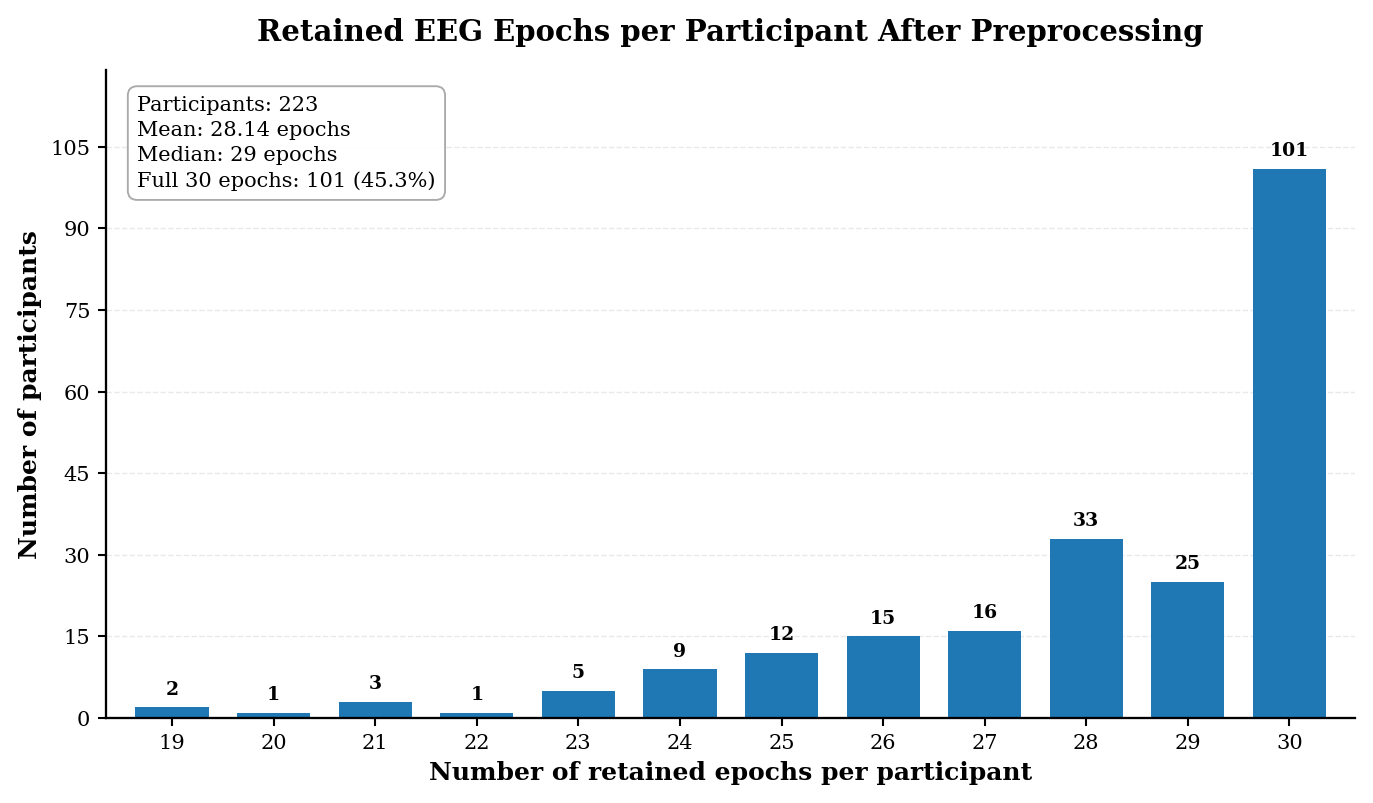


All publication figures were saved in:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/publication_figures


In [ ]:
# CELL 9 — Publication-quality figures

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# 1. Output directory
# ============================================================

FIG_DIR = (
    "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "publication_figures"
)

os.makedirs(FIG_DIR, exist_ok=True)

# ============================================================
# 2. Publication-style global settings
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.1,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


def clean_axes(ax, grid_axis="y"):
    """Apply a clean publication-style appearance."""

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=1
    )

    ax.grid(
        axis=grid_axis,
        linestyle="--",
        linewidth=0.7,
        alpha=0.28
    )

    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(
        MaxNLocator(integer=True)
    )


def save_figure(fig, filename):
    """Save a figure in PNG, PDF, and SVG formats."""

    for extension in ["png", "pdf", "svg"]:
        path = os.path.join(
            FIG_DIR,
            f"{filename}.{extension}"
        )

        fig.savefig(
            path,
            format=extension,
            bbox_inches="tight"
        )

    print(
        f"Saved: {filename}.png, "
        f"{filename}.pdf and "
        f"{filename}.svg"
    )


# ============================================================
# 3. Validate required columns
# ============================================================

required_columns = {
    "subject_id",
    "trial_num",
    "painrating",
    "pain_label",
    "pain_class"
}

missing_columns = required_columns.difference(
    meta_df.columns
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: "
        f"{sorted(missing_columns)}"
    )

# Generate participant-level summary
subject_label_summary = (
    meta_df
    .groupby("subject_id")
    .agg(
        n_trials=("trial_num", "count"),
        n_low=(
            "pain_label",
            lambda x: (x == 0).sum()
        ),
        n_high=(
            "pain_label",
            lambda x: (x == 1).sum()
        )
    )
    .reset_index()
)

total_epochs = len(meta_df)

total_subjects = (
    meta_df["subject_id"]
    .nunique()
)

# ============================================================
# FIGURE 1 — NRS pain-rating distribution
# ============================================================

rating_counts = (
    meta_df["painrating"]
    .value_counts()
    .reindex(range(11), fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    constrained_layout=True
)

bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    width=0.72
)

ax.set_title(
    "Distribution of Single-Trial Pain Ratings in the Dataset",
    pad=14
)

ax.set_xlabel(
    "Numerical Rating Scale pain score"
)

ax.set_ylabel(
    "Number of retained epochs"
)

ax.set_xticks(range(11))
ax.set_xlim(-0.65, 10.65)

upper_limit = rating_counts.max() * 1.16
ax.set_ylim(0, upper_limit)

clean_axes(ax)

# Count labels above bars
for bar, count in zip(
    bars,
    rating_counts.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + upper_limit * 0.015,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Dataset information box
ax.text(
    0.985,
    0.96,
    (
        f"Participants: {total_subjects}\n"
        f"Retained epochs: {total_epochs:,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    linespacing=1.4,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "0.65",
        "linewidth": 0.9,
        "alpha": 0.95
    }
)

save_figure(
    fig,
    "figure_1_nrs_pain_rating_distribution"
)

plt.show()

# ============================================================
# FIGURE 2 — Binary pain-class distribution
# ============================================================

class_order = [
    "low_pain",
    "high_pain"
]

class_counts = (
    meta_df["pain_class"]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

class_labels = [
    "Low pain\nNRS 0–4",
    "High pain\nNRS 5–10"
]

class_percentages = (
    class_counts /
    class_counts.sum() *
    100
)

fig, ax = plt.subplots(
    figsize=(6.3, 5.4),
    constrained_layout=True
)

bars = ax.bar(
    class_labels,
    class_counts.values,
    width=0.58
)

# Increased padding provides room for the information box
ax.set_title(
    "Binary Pain-Class Distribution in the Dataset",
    pad=58
)

ax.set_xlabel("Pain class")

ax.set_ylabel(
    "Number of retained epochs"
)

upper_limit = (
    class_counts.max() * 1.22
)

ax.set_ylim(
    0,
    upper_limit
)

clean_axes(ax)

# Add count and percentage above each bar
for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + upper_limit * 0.025,
        (
            f"{count:,}\n"
            f"({percentage:.1f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        linespacing=1.25
    )

# Calculate imbalance ratio
low_count = class_counts.loc["low_pain"]
high_count = class_counts.loc["high_pain"]

imbalance_ratio = (
    high_count / low_count
    if low_count > 0
    else np.nan
)

# ------------------------------------------------------------
# Corrected position:
# y = 1.02 places the box above the plotting area
# clip_on=False ensures that it remains visible
# ------------------------------------------------------------

ax.text(
    0.985,
    1.02,
    (
        f"Total epochs: {total_epochs:,}\n"
        f"High-to-low ratio: "
        f"{imbalance_ratio:.2f}:1"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    linespacing=1.4,
    clip_on=False,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "0.65",
        "linewidth": 0.9,
        "alpha": 0.95
    }
)

save_figure(
    fig,
    "figure_2_binary_pain_class_distribution"
)

plt.show()

# ============================================================
# FIGURE 3 — Retained epochs per participant
# ============================================================

epoch_count_distribution = (
    subject_label_summary["n_trials"]
    .value_counts()
    .sort_index()
)

full_epoch_range = range(
    int(
        subject_label_summary[
            "n_trials"
        ].min()
    ),
    int(
        subject_label_summary[
            "n_trials"
        ].max()
    ) + 1
)

epoch_count_distribution = (
    epoch_count_distribution
    .reindex(
        full_epoch_range,
        fill_value=0
    )
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    constrained_layout=True
)

bars = ax.bar(
    epoch_count_distribution.index,
    epoch_count_distribution.values,
    width=0.72
)

ax.set_title(
    "Retained EEG Epochs per Participant After Preprocessing",
    pad=14
)

ax.set_xlabel(
    "Number of retained epochs per participant"
)

ax.set_ylabel(
    "Number of participants"
)

ax.set_xticks(
    list(full_epoch_range)
)

ax.set_xlim(
    min(full_epoch_range) - 0.65,
    max(full_epoch_range) + 0.65
)

upper_limit = (
    epoch_count_distribution.max() *
    1.18
)

ax.set_ylim(
    0,
    upper_limit
)

clean_axes(ax)

# Count labels above bars
for bar, count in zip(
    bars,
    epoch_count_distribution.values
):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + upper_limit * 0.014,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

complete_subjects = int(
    (
        subject_label_summary["n_trials"] == 30
    ).sum()
)

complete_percentage = (
    complete_subjects /
    total_subjects *
    100
)

mean_epochs = (
    subject_label_summary["n_trials"]
    .mean()
)

median_epochs = (
    subject_label_summary["n_trials"]
    .median()
)

ax.text(
    0.025,
    0.96,
    (
        f"Participants: {total_subjects}\n"
        f"Mean: {mean_epochs:.2f} epochs\n"
        f"Median: {median_epochs:.0f} epochs\n"
        f"Full 30 epochs: {complete_subjects} "
        f"({complete_percentage:.1f}%)"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    linespacing=1.4,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "0.65",
        "linewidth": 0.9,
        "alpha": 0.95
    }
)

save_figure(
    fig,
    "figure_3_retained_epochs_per_participant"
)

plt.show()

# ============================================================
# 4. Print saved location
# ============================================================

print(
    "\nAll publication figures were saved in:"
)

print(FIG_DIR)

# V5 Main Pipeline — Full Feature Extraction

This section builds the proposed primary V5 representation:

1. Fixed 12-channel laser-evoked EEG montage.
2. Trial-wise baseline normalization for handcrafted LEP features.
3. Full handcrafted feature branch with no `SelectKBest`.
4. Baseline-referenced multi-view Riemannian covariance branch.
5. Full early fusion while preserving both branches separately.

The Riemannian branch uses:
- five broadband physiological response windows; and
- four full-response frequency-band covariance changes.

This avoids estimating very-low-frequency covariance from unrealistically
short time windows. No global scaler, supervised feature selector, CSP,
or classifier is fitted during feature extraction.

In [ ]:
# CELL 10 — V5 configuration, output paths, and selected channels

from scipy.signal import butter, sosfiltfilt, welch
from scipy.stats import skew, kurtosis

V5_DIR = os.path.join(
    OUT_DIR,
    "V5_MAIN_PIPELINE_12CH"
)
os.makedirs(V5_DIR, exist_ok=True)

# Original compact montage plus C3 and C4 for stronger bilateral
# central and contralateral N1/LEP coverage.
# FCz is excluded because it is absent from the Exp8 channel list.
V5_CHANNELS = [
    "Fz",
    "FC1", "FC2",
    "C3", "C1", "Cz", "C2", "C4",
    "CP1", "CPz", "CP2",
    "Pz",
]

FS_EXPECTED = 1000.0
BASELINE_RANGE_MS = (-1000.0, 0.0)
RESPONSE_RANGE_MS = (0.0, 1000.0)
BATCH_SIZE = 128

print("V5 output directory:", V5_DIR)
print("Selected channels:", V5_CHANNELS)
print("Number of selected channels:", len(V5_CHANNELS))
print("Primary experiment: use every extracted feature")
print("SelectKBest used:", False)


In [ ]:
# CELL 11 — Strict channel audit across all 223 subjects

def get_channel_labels_strict(chanlocs, nbchan):
    labels = []

    if isinstance(chanlocs, dict) and "labels" in chanlocs:
        labels = [
            str(value)
            for value in np.asarray(
                chanlocs["labels"],
                dtype=object
            ).flatten()
        ]

    elif isinstance(chanlocs, list):
        for channel in chanlocs:
            if isinstance(channel, dict) and "labels" in channel:
                labels.append(
                    str(safe_scalar(channel["labels"]))
                )

    labels = [
        clean_channel_name(label)
        for label in labels
        if str(label).strip() != ""
    ]

    if len(labels) != nbchan:
        raise ValueError(
            f"Channel-label count mismatch: "
            f"labels={len(labels)}, nbchan={nbchan}"
        )

    return labels


v5_inventory_rows = []
v5_missing_rows = []

for set_path in tqdm(
    set_files,
    desc="Auditing V5 channels"
):
    mat = read_mat(set_path)
    sid = get_subject_id(set_path)

    nbchan = int(safe_scalar(mat["nbchan"]))
    labels = get_channel_labels_strict(
        mat.get("chanlocs", []),
        nbchan
    )

    label_set = set(labels)
    missing = [
        channel
        for channel in V5_CHANNELS
        if clean_channel_name(channel) not in label_set
    ]

    v5_inventory_rows.append({
        "subject_id": sid,
        "source_file": os.path.basename(set_path),
        "nbchan": nbchan,
        "pnts": int(safe_scalar(mat["pnts"])),
        "trials": int(safe_scalar(mat["trials"])),
        "srate": float(safe_scalar(mat["srate"])),
        "xmin": float(safe_scalar(mat.get("xmin", np.nan))),
        "xmax": float(safe_scalar(mat.get("xmax", np.nan))),
    })

    if missing:
        v5_missing_rows.append({
            "subject_id": sid,
            "source_file": os.path.basename(set_path),
            "missing_channels": ", ".join(missing),
        })

v5_inventory_df = pd.DataFrame(v5_inventory_rows)
v5_missing_df = pd.DataFrame(v5_missing_rows)

v5_inventory_df.to_csv(
    os.path.join(V5_DIR, "v5_subject_inventory.csv"),
    index=False
)
v5_missing_df.to_csv(
    os.path.join(V5_DIR, "v5_missing_channels.csv"),
    index=False
)

print("Subjects audited:", len(v5_inventory_df))
print(
    "Total retained epochs:",
    int(v5_inventory_df["trials"].sum())
)
print(
    "Sampling rates:",
    sorted(v5_inventory_df["srate"].unique())
)
print("\nChannel-count distribution:")
display(
    v5_inventory_df["nbchan"]
    .value_counts()
    .sort_index()
)

if not v5_missing_df.empty:
    display(v5_missing_df)
    raise ValueError(
        "At least one selected V5 channel is missing."
    )

if len(v5_inventory_df) != 223:
    raise ValueError(
        f"Expected 223 subjects, found {len(v5_inventory_df)}."
    )

if not np.allclose(
    v5_inventory_df["srate"].to_numpy(),
    FS_EXPECTED
):
    raise ValueError("Unexpected sampling rate detected.")

print("\nAll 12 V5 channels are present in every subject.")


In [ ]:
# CELL 12 — Read .set/.fdt files and save aligned 12-channel epochs

X_BASELINE_PATH = os.path.join(
    V5_DIR,
    "X_v5_baseline_raw_12ch.npy"
)
X_RESPONSE_PATH = os.path.join(
    V5_DIR,
    "X_v5_response_raw_12ch.npy"
)
V5_METADATA_PATH = os.path.join(
    V5_DIR,
    "v5_metadata_aligned.csv"
)

first_mat = read_mat(set_files[0])
first_times = get_times_ms(first_mat)

baseline_indices = np.where(
    (first_times >= BASELINE_RANGE_MS[0])
    & (first_times < BASELINE_RANGE_MS[1])
)[0]

response_indices = np.where(
    (first_times >= RESPONSE_RANGE_MS[0])
    & (first_times < RESPONSE_RANGE_MS[1])
)[0]

if len(baseline_indices) != 1000:
    raise ValueError(
        f"Expected 1000 baseline samples, "
        f"found {len(baseline_indices)}."
    )

if len(response_indices) != 1000:
    raise ValueError(
        f"Expected 1000 response samples, "
        f"found {len(response_indices)}."
    )

baseline_times_ms = first_times[baseline_indices]
response_times_ms = first_times[response_indices]

np.save(
    os.path.join(V5_DIR, "baseline_times_ms.npy"),
    baseline_times_ms
)
np.save(
    os.path.join(V5_DIR, "response_times_ms.npy"),
    response_times_ms
)
pd.DataFrame({"channel": V5_CHANNELS}).to_csv(
    os.path.join(V5_DIR, "v5_selected_channels.csv"),
    index=False
)

n_total_epochs = int(v5_inventory_df["trials"].sum())
n_v5_channels = len(V5_CHANNELS)

X_v5_baseline = np.lib.format.open_memmap(
    X_BASELINE_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        n_total_epochs,
        n_v5_channels,
        len(baseline_indices)
    )
)

X_v5_response = np.lib.format.open_memmap(
    X_RESPONSE_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        n_total_epochs,
        n_v5_channels,
        len(response_indices)
    )
)

aligned_metadata_rows = []
cursor = 0

for set_path in tqdm(
    set_files,
    desc="Extracting aligned 12-channel epochs"
):
    mat = read_mat(set_path)
    sid = get_subject_id(set_path)

    data = load_eeg_data_from_set(
        mat,
        set_path,
        REREFER_DIR
    )

    nbchan = int(safe_scalar(mat["nbchan"]))
    n_trials = int(safe_scalar(mat["trials"]))

    labels = get_channel_labels_strict(
        mat.get("chanlocs", []),
        nbchan
    )
    label_to_index = {
        clean_channel_name(channel): index
        for index, channel in enumerate(labels)
    }

    channel_indices = [
        label_to_index[clean_channel_name(channel)]
        for channel in V5_CHANNELS
    ]

    current_times = get_times_ms(mat)
    current_baseline_indices = np.where(
        (current_times >= BASELINE_RANGE_MS[0])
        & (current_times < BASELINE_RANGE_MS[1])
    )[0]
    current_response_indices = np.where(
        (current_times >= RESPONSE_RANGE_MS[0])
        & (current_times < RESPONSE_RANGE_MS[1])
    )[0]

    if not np.allclose(
        current_times[current_baseline_indices],
        baseline_times_ms
    ):
        raise ValueError(
            f"Baseline time grid mismatch in {set_path}."
        )

    if not np.allclose(
        current_times[current_response_indices],
        response_times_ms
    ):
        raise ValueError(
            f"Response time grid mismatch in {set_path}."
        )

    selected = data[channel_indices, :, :]

    baseline_block = np.transpose(
        selected[:, current_baseline_indices, :],
        (2, 0, 1)
    ).astype(np.float32, copy=False)

    response_block = np.transpose(
        selected[:, current_response_indices, :],
        (2, 0, 1)
    ).astype(np.float32, copy=False)

    start = cursor
    stop = cursor + n_trials

    X_v5_baseline[start:stop] = baseline_block
    X_v5_response[start:stop] = response_block

    pain, laser, event_type = (
        extract_trial_metadata_from_epoch(
            mat,
            n_trials
        )
    )

    for trial_index in range(n_trials):
        aligned_metadata_rows.append({
            "experiment": EXP_NAME,
            "subject_id": sid,
            "trial_num": trial_index + 1,
            "painrating": safe_scalar(
                pain[trial_index]
            ),
            "laser_power": safe_scalar(
                laser[trial_index]
            ),
            "event_type": safe_scalar(
                event_type[trial_index]
            ),
            "source_file": os.path.basename(set_path),
        })

    cursor = stop

    del (
        mat,
        data,
        selected,
        baseline_block,
        response_block
    )

X_v5_baseline.flush()
X_v5_response.flush()

if cursor != n_total_epochs:
    raise RuntimeError(
        f"Extracted {cursor} epochs; "
        f"expected {n_total_epochs}."
    )

v5_meta_df = pd.DataFrame(aligned_metadata_rows)

v5_meta_df["painrating"] = pd.to_numeric(
    v5_meta_df["painrating"],
    errors="coerce"
)
v5_meta_df["laser_power"] = pd.to_numeric(
    v5_meta_df["laser_power"],
    errors="coerce"
)

if v5_meta_df["painrating"].isna().any():
    raise ValueError("Missing pain ratings found.")

if v5_meta_df["laser_power"].isna().any():
    raise ValueError("Missing laser-power values found.")

v5_meta_df["pain_label"] = (
    v5_meta_df["painrating"] >= 5
).astype(np.int8)

v5_meta_df["pain_class"] = np.where(
    v5_meta_df["pain_label"] == 1,
    "high_pain",
    "low_pain"
)

# Compare the newly generated metadata against the metadata
# already loaded in the original part of this notebook.
alignment_columns = [
    "subject_id",
    "trial_num",
    "source_file"
]

if not v5_meta_df[alignment_columns].reset_index(
    drop=True
).equals(
    meta_df[alignment_columns].reset_index(drop=True)
):
    raise ValueError(
        "V5 epoch rows do not match the existing metadata order."
    )

if not np.allclose(
    v5_meta_df["painrating"].to_numpy(float),
    meta_df["painrating"].to_numpy(float)
):
    raise ValueError(
        "Pain-rating alignment mismatch."
    )

if not np.allclose(
    v5_meta_df["laser_power"].to_numpy(float),
    meta_df["laser_power"].to_numpy(float)
):
    raise ValueError(
        "Laser-power alignment mismatch."
    )

v5_meta_df.to_csv(
    V5_METADATA_PATH,
    index=False
)

np.save(
    os.path.join(V5_DIR, "y_v5_binary.npy"),
    v5_meta_df["pain_label"].to_numpy(np.int8)
)
np.save(
    os.path.join(V5_DIR, "groups_v5_subject.npy"),
    v5_meta_df["subject_id"].to_numpy()
)
np.save(
    os.path.join(V5_DIR, "painrating_v5.npy"),
    v5_meta_df["painrating"].to_numpy(np.float32)
)
np.save(
    os.path.join(V5_DIR, "laser_power_v5.npy"),
    v5_meta_df["laser_power"].to_numpy(np.float32)
)

print("Baseline epochs:", X_v5_baseline.shape)
print("Response epochs:", X_v5_response.shape)
print("Metadata:", v5_meta_df.shape)
print(
    "Class counts [low, high]:",
    np.bincount(v5_meta_df["pain_label"])
)
print("Epoch/metadata alignment verified.")


In [ ]:
# CELL 13 — Reload arrays and perform strict V5 quality control

X_v5_baseline = np.load(
    X_BASELINE_PATH,
    mmap_mode="r"
)
X_v5_response = np.load(
    X_RESPONSE_PATH,
    mmap_mode="r"
)
v5_meta_df = pd.read_csv(V5_METADATA_PATH)

y_v5 = v5_meta_df["pain_label"].to_numpy(np.int8)
groups_v5 = v5_meta_df["subject_id"].to_numpy()
painrating_v5 = v5_meta_df[
    "painrating"
].to_numpy(np.float32)
laser_power_v5 = v5_meta_df[
    "laser_power"
].to_numpy(np.float32)

assert X_v5_baseline.shape == X_v5_response.shape
assert X_v5_baseline.shape == (6275, 12, 1000)
assert len(y_v5) == 6275
assert len(groups_v5) == 6275
assert len(np.unique(groups_v5)) == 223
assert np.array_equal(
    np.bincount(y_v5),
    np.array([2725, 3550])
)

minimum_baseline_sd = np.inf

for start in tqdm(
    range(0, len(y_v5), BATCH_SIZE),
    desc="Checking V5 epoch arrays"
):
    stop = min(
        start + BATCH_SIZE,
        len(y_v5)
    )

    baseline_batch = np.asarray(
        X_v5_baseline[start:stop]
    )
    response_batch = np.asarray(
        X_v5_response[start:stop]
    )

    if not np.isfinite(baseline_batch).all():
        raise ValueError(
            f"Non-finite baseline values in "
            f"rows {start}:{stop}."
        )

    if not np.isfinite(response_batch).all():
        raise ValueError(
            f"Non-finite response values in "
            f"rows {start}:{stop}."
        )

    current_sd = baseline_batch.std(axis=-1)
    minimum_baseline_sd = min(
        minimum_baseline_sd,
        float(current_sd.min())
    )

    if np.any(current_sd < 1e-8):
        raise ValueError(
            f"Near-zero baseline variance in "
            f"rows {start}:{stop}."
        )

print("All V5 quality checks passed.")
print(
    "Minimum trial/channel baseline SD:",
    minimum_baseline_sd
)


In [ ]:
# CELL 14 — Define all handcrafted V5 features

# Gamma is not extracted from the stored rereferenced data.
# The full valid handcrafted representation is retained:
# 21 features/channel × 12 channels + 10 global = 262.

HANDCRAFTED_WINDOWS = {
    "early_0_200": (0, 200),
    "n2_180_350": (180, 350),
    "p2_300_600": (300, 600),
    "late_600_1000": (600, 1000),
    "global_0_1000": (0, 1000),
}

HANDCRAFTED_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
}


def histogram_entropy(signal, bins=20):
    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)]

    if signal.size == 0:
        return np.nan

    counts, _ = np.histogram(
        signal,
        bins=bins
    )
    probabilities = counts.astype(float)
    probabilities = probabilities[
        probabilities > 0
    ]
    probabilities /= probabilities.sum()

    return float(
        -np.sum(
            probabilities
            * np.log(probabilities + 1e-12)
        )
    )


def create_handcrafted_feature_names(channels):
    per_channel = [
        *[
            f"{window_name}_mean"
            for window_name in HANDCRAFTED_WINDOWS
        ],
        "n2_amp",
        "n2_latency_ms",
        "p2_amp",
        "p2_latency_ms",
        "n2p2_peak_to_peak",
        *[
            f"{band_name}_power"
            for band_name in HANDCRAFTED_BANDS
        ],
        "hjorth_activity",
        "hjorth_mobility",
        "hjorth_complexity",
        "entropy",
        "standard_deviation",
        "skewness",
        "kurtosis",
    ]

    names = []

    for channel in channels:
        names.extend([
            f"{channel}__{feature_name}"
            for feature_name in per_channel
        ])

    names.extend([
        *[
            f"GLOBAL__{window_name}_mean"
            for window_name in HANDCRAFTED_WINDOWS
        ],
        "GLOBAL__n2_amp",
        "GLOBAL__n2_latency_ms",
        "GLOBAL__p2_amp",
        "GLOBAL__p2_latency_ms",
        "GLOBAL__n2p2_peak_to_peak",
    ])

    return names


V5_HANDCRAFTED_NAMES = (
    create_handcrafted_feature_names(
        V5_CHANNELS
    )
)

print(
    "Handcrafted feature count:",
    len(V5_HANDCRAFTED_NAMES)
)

assert len(V5_HANDCRAFTED_NAMES) == 262


In [ ]:
# CELL 15 — Extract all 262 baseline-normalized handcrafted features

X_HANDCRAFTED_PATH = os.path.join(
    V5_DIR,
    "X_v5_handcrafted_all_262.npy"
)
HANDCRAFTED_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_handcrafted_feature_names_262.csv"
)

response_times_ms = np.load(
    os.path.join(V5_DIR, "response_times_ms.npy")
)

handcrafted_window_indices = {
    name: np.where(
        (response_times_ms >= start_ms)
        & (response_times_ms < end_ms)
    )[0]
    for name, (start_ms, end_ms)
    in HANDCRAFTED_WINDOWS.items()
}

n2_indices = np.where(
    (response_times_ms >= 180)
    & (response_times_ms < 350)
)[0]

p2_indices = np.where(
    (response_times_ms >= 300)
    & (response_times_ms < 600)
)[0]

X_v5_handcrafted = np.lib.format.open_memmap(
    X_HANDCRAFTED_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        len(y_v5),
        len(V5_HANDCRAFTED_NAMES)
    )
)

for start in tqdm(
    range(0, len(y_v5), BATCH_SIZE),
    desc="Extracting V5 handcrafted features"
):
    stop = min(
        start + BATCH_SIZE,
        len(y_v5)
    )

    baseline_batch = np.asarray(
        X_v5_baseline[start:stop],
        dtype=np.float64
    )
    response_batch = np.asarray(
        X_v5_response[start:stop],
        dtype=np.float64
    )

    baseline_mean = baseline_batch.mean(
        axis=-1,
        keepdims=True
    )
    baseline_sd = baseline_batch.std(
        axis=-1,
        keepdims=True
    )
    baseline_sd = np.maximum(
        baseline_sd,
        1e-8
    )

    # Same-trial, same-channel baseline z-normalization.
    normalized_response = (
        response_batch - baseline_mean
    ) / baseline_sd

    current_batch_size = (
        normalized_response.shape[0]
    )
    n_channels = normalized_response.shape[1]

    channel_features = np.empty(
        (
            current_batch_size,
            n_channels,
            21
        ),
        dtype=np.float64
    )

    feature_index = 0

    # Five temporal mean features.
    for window_name in HANDCRAFTED_WINDOWS:
        indices = handcrafted_window_indices[
            window_name
        ]
        channel_features[
            :,
            :,
            feature_index
        ] = normalized_response[
            :,
            :,
            indices
        ].mean(axis=-1)
        feature_index += 1

    # N2 and P2 morphology.
    n2_segment = normalized_response[
        :,
        :,
        n2_indices
    ]
    n2_argmin = np.argmin(
        n2_segment,
        axis=-1
    )
    n2_amplitude = np.take_along_axis(
        n2_segment,
        n2_argmin[..., None],
        axis=-1
    )[..., 0]
    n2_latency = (
        response_times_ms[n2_indices][
            n2_argmin
        ]
    )

    p2_segment = normalized_response[
        :,
        :,
        p2_indices
    ]
    p2_argmax = np.argmax(
        p2_segment,
        axis=-1
    )
    p2_amplitude = np.take_along_axis(
        p2_segment,
        p2_argmax[..., None],
        axis=-1
    )[..., 0]
    p2_latency = (
        response_times_ms[p2_indices][
            p2_argmax
        ]
    )

    for values in [
        n2_amplitude,
        n2_latency,
        p2_amplitude,
        p2_latency,
        p2_amplitude - n2_amplitude,
    ]:
        channel_features[
            :,
            :,
            feature_index
        ] = values
        feature_index += 1

    # Delta, theta, alpha, and beta power.
    frequencies, power_spectral_density = welch(
        normalized_response,
        fs=FS_EXPECTED,
        nperseg=min(
            512,
            normalized_response.shape[-1]
        ),
        axis=-1
    )

    for fmin, fmax in HANDCRAFTED_BANDS.values():
        frequency_mask = (
            (frequencies >= fmin)
            & (frequencies <= fmax)
        )

        channel_features[
            :,
            :,
            feature_index
        ] = np.trapz(
            power_spectral_density[
                :,
                :,
                frequency_mask
            ],
            frequencies[frequency_mask],
            axis=-1
        )
        feature_index += 1

    # Hjorth parameters.
    first_difference = np.diff(
        normalized_response,
        axis=-1
    )
    second_difference = np.diff(
        first_difference,
        axis=-1
    )

    variance_zero = np.var(
        normalized_response,
        axis=-1
    )
    variance_one = np.var(
        first_difference,
        axis=-1
    )
    variance_two = np.var(
        second_difference,
        axis=-1
    )

    mobility = np.sqrt(
        np.divide(
            variance_one,
            variance_zero,
            out=np.zeros_like(variance_one),
            where=variance_zero > 0
        )
    )

    complexity = np.divide(
        np.sqrt(
            np.divide(
                variance_two,
                variance_one,
                out=np.zeros_like(variance_two),
                where=variance_one > 0
            )
        ),
        mobility,
        out=np.zeros_like(mobility),
        where=mobility > 0
    )

    for values in [
        variance_zero,
        mobility,
        complexity,
    ]:
        channel_features[
            :,
            :,
            feature_index
        ] = values
        feature_index += 1

    entropy_values = np.empty(
        (
            current_batch_size,
            n_channels
        ),
        dtype=np.float64
    )

    for row_index in range(
        current_batch_size
    ):
        for channel_index in range(
            n_channels
        ):
            entropy_values[
                row_index,
                channel_index
            ] = histogram_entropy(
                normalized_response[
                    row_index,
                    channel_index
                ]
            )

    channel_features[
        :,
        :,
        feature_index
    ] = entropy_values
    feature_index += 1

    channel_features[
        :,
        :,
        feature_index
    ] = np.std(
        normalized_response,
        axis=-1
    )
    feature_index += 1

    channel_features[
        :,
        :,
        feature_index
    ] = skew(
        normalized_response,
        axis=-1,
        bias=False,
        nan_policy="omit"
    )
    feature_index += 1

    channel_features[
        :,
        :,
        feature_index
    ] = kurtosis(
        normalized_response,
        axis=-1,
        bias=False,
        nan_policy="omit"
    )
    feature_index += 1

    assert feature_index == 21

    # Ten global features from the 12-channel average.
    global_signal = normalized_response.mean(
        axis=1
    )
    global_features = np.empty(
        (
            current_batch_size,
            10
        ),
        dtype=np.float64
    )

    global_index = 0

    for window_name in HANDCRAFTED_WINDOWS:
        indices = handcrafted_window_indices[
            window_name
        ]
        global_features[
            :,
            global_index
        ] = global_signal[
            :,
            indices
        ].mean(axis=-1)
        global_index += 1

    global_n2_segment = global_signal[
        :,
        n2_indices
    ]
    global_n2_argmin = np.argmin(
        global_n2_segment,
        axis=-1
    )
    global_n2_amplitude = np.take_along_axis(
        global_n2_segment,
        global_n2_argmin[:, None],
        axis=-1
    )[:, 0]
    global_n2_latency = (
        response_times_ms[n2_indices][
            global_n2_argmin
        ]
    )

    global_p2_segment = global_signal[
        :,
        p2_indices
    ]
    global_p2_argmax = np.argmax(
        global_p2_segment,
        axis=-1
    )
    global_p2_amplitude = np.take_along_axis(
        global_p2_segment,
        global_p2_argmax[:, None],
        axis=-1
    )[:, 0]
    global_p2_latency = (
        response_times_ms[p2_indices][
            global_p2_argmax
        ]
    )

    for values in [
        global_n2_amplitude,
        global_n2_latency,
        global_p2_amplitude,
        global_p2_latency,
        (
            global_p2_amplitude
            - global_n2_amplitude
        ),
    ]:
        global_features[
            :,
            global_index
        ] = values
        global_index += 1

    assert global_index == 10

    batch_features = np.concatenate(
        [
            channel_features.reshape(
                current_batch_size,
                -1
            ),
            global_features,
        ],
        axis=1
    )

    if batch_features.shape[1] != 262:
        raise RuntimeError(
            f"Unexpected handcrafted count: "
            f"{batch_features.shape[1]}"
        )

    if not np.isfinite(batch_features).all():
        raise ValueError(
            f"Non-finite handcrafted features "
            f"in rows {start}:{stop}."
        )

    X_v5_handcrafted[
        start:stop
    ] = batch_features.astype(np.float32)

    X_v5_handcrafted.flush()

pd.DataFrame({
    "feature_no": np.arange(
        1,
        len(V5_HANDCRAFTED_NAMES) + 1
    ),
    "feature_name": V5_HANDCRAFTED_NAMES,
}).to_csv(
    HANDCRAFTED_NAMES_PATH,
    index=False
)

print(
    "Handcrafted feature matrix:",
    X_v5_handcrafted.shape
)
print("Saved:", X_HANDCRAFTED_PATH)


In [ ]:
# CELL 16 — Baseline-referenced Riemannian helper functions

# Five broadband physiological windows plus four full-response
# frequency-band covariance changes.
RIEMANNIAN_TIME_WINDOWS = {
    "broadband_early_0_200": (0, 200),
    "broadband_n2_180_350": (180, 350),
    "broadband_p2_300_600": (300, 600),
    "broadband_late_600_1000": (600, 1000),
    "broadband_global_0_1000": (0, 1000),
}

RIEMANNIAN_FREQUENCY_BANDS = {
    "delta_full_0_1000": (1, 4),
    "theta_full_0_1000": (4, 8),
    "alpha_full_0_1000": (8, 13),
    "beta_full_0_1000": (13, 30),
}


def batch_oas_covariance(
    signals,
    epsilon=1e-10
):
    signals = np.asarray(
        signals,
        dtype=np.float64
    )

    batch_size, n_channels, n_samples = (
        signals.shape
    )

    centered = signals - signals.mean(
        axis=-1,
        keepdims=True
    )

    empirical = np.einsum(
        "bct,bdt->bcd",
        centered,
        centered,
        optimize=True
    ) / float(n_samples)

    alpha = np.mean(
        empirical ** 2,
        axis=(1, 2)
    )
    mu = np.trace(
        empirical,
        axis1=1,
        axis2=2
    ) / float(n_channels)
    mu_squared = mu ** 2

    numerator = alpha + mu_squared
    denominator = (
        (n_samples + 1.0)
        * (
            alpha
            - mu_squared / float(n_channels)
        )
    )

    shrinkage = np.ones(
        batch_size,
        dtype=np.float64
    )
    valid = np.abs(denominator) > epsilon

    shrinkage[valid] = np.minimum(
        numerator[valid]
        / denominator[valid],
        1.0
    )
    shrinkage = np.clip(
        shrinkage,
        0.0,
        1.0
    )

    covariance = (
        (1.0 - shrinkage)[:, None, None]
        * empirical
    )

    diagonal = np.arange(n_channels)
    covariance[
        :,
        diagonal,
        diagonal
    ] += shrinkage[:, None] * mu[:, None]

    scale = np.maximum(mu, epsilon)
    covariance[
        :,
        diagonal,
        diagonal
    ] += epsilon * scale[:, None]

    covariance = 0.5 * (
        covariance
        + np.transpose(
            covariance,
            (0, 2, 1)
        )
    )

    return covariance


def batch_spd_inverse_sqrt(
    matrices,
    epsilon=1e-10
):
    eigenvalues, eigenvectors = np.linalg.eigh(
        matrices
    )
    eigenvalues = np.clip(
        eigenvalues,
        epsilon,
        None
    )

    scaled_vectors = (
        eigenvectors
        * (
            eigenvalues ** -0.5
        )[:, None, :]
    )

    return (
        scaled_vectors
        @ np.transpose(
            eigenvectors,
            (0, 2, 1)
        )
    )


def batch_spd_log(
    matrices,
    epsilon=1e-10
):
    matrices = 0.5 * (
        matrices
        + np.transpose(
            matrices,
            (0, 2, 1)
        )
    )

    eigenvalues, eigenvectors = np.linalg.eigh(
        matrices
    )
    eigenvalues = np.clip(
        eigenvalues,
        epsilon,
        None
    )

    scaled_vectors = (
        eigenvectors
        * np.log(eigenvalues)[:, None, :]
    )

    logged = (
        scaled_vectors
        @ np.transpose(
            eigenvectors,
            (0, 2, 1)
        )
    )

    return 0.5 * (
        logged
        + np.transpose(
            logged,
            (0, 2, 1)
        )
    )


def batch_relative_log_covariance(
    baseline_covariance,
    response_covariance
):
    inverse_sqrt = batch_spd_inverse_sqrt(
        baseline_covariance
    )

    relative_covariance = (
        inverse_sqrt
        @ response_covariance
        @ inverse_sqrt
    )

    relative_covariance = 0.5 * (
        relative_covariance
        + np.transpose(
            relative_covariance,
            (0, 2, 1)
        )
    )

    return batch_spd_log(
        relative_covariance
    )


def vectorize_symmetric_matrices(matrices):
    n_channels = matrices.shape[1]
    row_indices, column_indices = (
        np.triu_indices(n_channels)
    )

    vectors = matrices[
        :,
        row_indices,
        column_indices
    ].copy()

    off_diagonal = (
        row_indices != column_indices
    )
    vectors[
        :,
        off_diagonal
    ] *= np.sqrt(2.0)

    return vectors


def create_riemannian_feature_names(
    representation_names,
    channels
):
    row_indices, column_indices = (
        np.triu_indices(len(channels))
    )

    names = []

    for representation in representation_names:
        for row_index, column_index in zip(
            row_indices,
            column_indices
        ):
            names.append(
                "RIEM__"
                f"{representation}__"
                f"{channels[row_index]}_"
                f"{channels[column_index]}"
            )

    return names


RIEMANNIAN_REPRESENTATIONS = [
    *RIEMANNIAN_TIME_WINDOWS.keys(),
    *RIEMANNIAN_FREQUENCY_BANDS.keys(),
]

V5_RIEMANNIAN_NAMES = (
    create_riemannian_feature_names(
        RIEMANNIAN_REPRESENTATIONS,
        V5_CHANNELS
    )
)

features_per_covariance = (
    len(V5_CHANNELS)
    * (len(V5_CHANNELS) + 1)
    // 2
)

print(
    "Riemannian representations:",
    RIEMANNIAN_REPRESENTATIONS
)
print(
    "Features per covariance:",
    features_per_covariance
)
print(
    "Total Riemannian features:",
    len(V5_RIEMANNIAN_NAMES)
)

assert features_per_covariance == 78
assert len(V5_RIEMANNIAN_NAMES) == 702


In [ ]:
# CELL 17 — Extract all 702 baseline-referenced Riemannian features

X_RIEMANNIAN_PATH = os.path.join(
    V5_DIR,
    "X_v5_baseline_referenced_riemannian_all_702.npy"
)
RIEMANNIAN_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_riemannian_feature_names_702.csv"
)

response_times_ms = np.load(
    os.path.join(V5_DIR, "response_times_ms.npy")
)

riemannian_window_indices = {
    name: np.where(
        (response_times_ms >= start_ms)
        & (response_times_ms < end_ms)
    )[0]
    for name, (start_ms, end_ms)
    in RIEMANNIAN_TIME_WINDOWS.items()
}

frequency_filters = {
    name: butter(
        4,
        [fmin, fmax],
        btype="bandpass",
        fs=FS_EXPECTED,
        output="sos"
    )
    for name, (fmin, fmax)
    in RIEMANNIAN_FREQUENCY_BANDS.items()
}

X_v5_riemannian = np.lib.format.open_memmap(
    X_RIEMANNIAN_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        len(y_v5),
        len(V5_RIEMANNIAN_NAMES)
    )
)

for start in tqdm(
    range(0, len(y_v5), BATCH_SIZE),
    desc="Extracting V5 Riemannian features"
):
    stop = min(
        start + BATCH_SIZE,
        len(y_v5)
    )

    baseline_batch = np.asarray(
        X_v5_baseline[start:stop],
        dtype=np.float64
    )
    response_batch = np.asarray(
        X_v5_response[start:stop],
        dtype=np.float64
    )

    batch_parts = []

    # Broadband baseline-reference for five physiological windows.
    broadband_baseline_covariance = (
        batch_oas_covariance(
            baseline_batch
        )
    )

    for representation_name in (
        RIEMANNIAN_TIME_WINDOWS
    ):
        window_indices = (
            riemannian_window_indices[
                representation_name
            ]
        )

        response_covariance = (
            batch_oas_covariance(
                response_batch[
                    :,
                    :,
                    window_indices
                ]
            )
        )

        relative_log_covariance = (
            batch_relative_log_covariance(
                broadband_baseline_covariance,
                response_covariance
            )
        )

        batch_parts.append(
            vectorize_symmetric_matrices(
                relative_log_covariance
            )
        )

    # Filter baseline and response together to reduce filter-edge
    # discontinuity at stimulus onset, then split the result.
    continuous_batch = np.concatenate(
        [
            baseline_batch,
            response_batch
        ],
        axis=-1
    )
    split_index = baseline_batch.shape[-1]

    for representation_name, sos_filter in (
        frequency_filters.items()
    ):
        filtered = sosfiltfilt(
            sos_filter,
            continuous_batch,
            axis=-1
        )

        filtered_baseline = filtered[
            :,
            :,
            :split_index
        ]
        filtered_response = filtered[
            :,
            :,
            split_index:
        ]

        baseline_covariance = (
            batch_oas_covariance(
                filtered_baseline
            )
        )
        response_covariance = (
            batch_oas_covariance(
                filtered_response
            )
        )

        relative_log_covariance = (
            batch_relative_log_covariance(
                baseline_covariance,
                response_covariance
            )
        )

        batch_parts.append(
            vectorize_symmetric_matrices(
                relative_log_covariance
            )
        )

        del (
            filtered,
            filtered_baseline,
            filtered_response
        )

    batch_features = np.concatenate(
        batch_parts,
        axis=1
    )

    if batch_features.shape[1] != 702:
        raise RuntimeError(
            f"Unexpected Riemannian count: "
            f"{batch_features.shape[1]}"
        )

    if not np.isfinite(batch_features).all():
        raise ValueError(
            f"Non-finite Riemannian features "
            f"in rows {start}:{stop}."
        )

    X_v5_riemannian[
        start:stop
    ] = batch_features.astype(np.float32)

    X_v5_riemannian.flush()

pd.DataFrame({
    "feature_no": np.arange(
        1,
        len(V5_RIEMANNIAN_NAMES) + 1
    ),
    "feature_name": V5_RIEMANNIAN_NAMES,
}).to_csv(
    RIEMANNIAN_NAMES_PATH,
    index=False
)

print(
    "Riemannian feature matrix:",
    X_v5_riemannian.shape
)
print("Saved:", X_RIEMANNIAN_PATH)


In [ ]:
# CELL 18 — Create the full V5 early-fusion feature matrix

X_FUSION_PATH = os.path.join(
    V5_DIR,
    "X_v5_full_fusion_all_964.npy"
)
FUSION_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_fusion_feature_names_964.csv"
)

X_v5_handcrafted = np.load(
    X_HANDCRAFTED_PATH,
    mmap_mode="r"
)
X_v5_riemannian = np.load(
    X_RIEMANNIAN_PATH,
    mmap_mode="r"
)

assert X_v5_handcrafted.shape == (
    6275,
    262
)
assert X_v5_riemannian.shape == (
    6275,
    702
)

V5_FUSION_NAMES = [
    *[
        f"HAND__{name}"
        for name in V5_HANDCRAFTED_NAMES
    ],
    *V5_RIEMANNIAN_NAMES,
]

assert len(V5_FUSION_NAMES) == 964

X_v5_fusion = np.lib.format.open_memmap(
    X_FUSION_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        len(y_v5),
        len(V5_FUSION_NAMES)
    )
)

for start in tqdm(
    range(0, len(y_v5), BATCH_SIZE),
    desc="Saving full V5 fusion"
):
    stop = min(
        start + BATCH_SIZE,
        len(y_v5)
    )

    X_v5_fusion[
        start:stop,
        :262
    ] = X_v5_handcrafted[start:stop]

    X_v5_fusion[
        start:stop,
        262:
    ] = X_v5_riemannian[start:stop]

X_v5_fusion.flush()

pd.DataFrame({
    "feature_no": np.arange(
        1,
        len(V5_FUSION_NAMES) + 1
    ),
    "feature_name": V5_FUSION_NAMES,
}).to_csv(
    FUSION_NAMES_PATH,
    index=False
)

print(
    "Handcrafted:",
    X_v5_handcrafted.shape
)
print(
    "Riemannian:",
    X_v5_riemannian.shape
)
print(
    "Full fusion:",
    X_v5_fusion.shape
)
print("Saved:", X_FUSION_PATH)


In [ ]:
# CELL 19 — Final V5 verification and saved-file manifest

X_v5_handcrafted = np.load(
    X_HANDCRAFTED_PATH,
    mmap_mode="r"
)
X_v5_riemannian = np.load(
    X_RIEMANNIAN_PATH,
    mmap_mode="r"
)
X_v5_fusion = np.load(
    X_FUSION_PATH,
    mmap_mode="r"
)

assert X_v5_handcrafted.shape == (6275, 262)
assert X_v5_riemannian.shape == (6275, 702)
assert X_v5_fusion.shape == (6275, 964)
assert len(y_v5) == 6275
assert len(groups_v5) == 6275
assert len(np.unique(groups_v5)) == 223
assert np.array_equal(
    np.bincount(y_v5),
    np.array([2725, 3550])
)

verification_rows = np.unique(
    np.linspace(
        0,
        len(y_v5) - 1,
        num=100,
        dtype=int
    )
)

assert np.isfinite(
    X_v5_handcrafted[verification_rows]
).all()
assert np.isfinite(
    X_v5_riemannian[verification_rows]
).all()
assert np.isfinite(
    X_v5_fusion[verification_rows]
).all()

manifest = pd.DataFrame([
    {
        "artifact": os.path.basename(
            X_BASELINE_PATH
        ),
        "shape": str(X_v5_baseline.shape),
        "role": "Raw prestimulus baseline epochs",
    },
    {
        "artifact": os.path.basename(
            X_RESPONSE_PATH
        ),
        "shape": str(X_v5_response.shape),
        "role": "Raw poststimulus response epochs",
    },
    {
        "artifact": os.path.basename(
            X_HANDCRAFTED_PATH
        ),
        "shape": str(X_v5_handcrafted.shape),
        "role": "Full handcrafted LEP branch",
    },
    {
        "artifact": os.path.basename(
            X_RIEMANNIAN_PATH
        ),
        "shape": str(X_v5_riemannian.shape),
        "role": (
            "Baseline-referenced "
            "Riemannian branch"
        ),
    },
    {
        "artifact": os.path.basename(
            X_FUSION_PATH
        ),
        "shape": str(X_v5_fusion.shape),
        "role": "Full early-fusion representation",
    },
    {
        "artifact": os.path.basename(
            V5_METADATA_PATH
        ),
        "shape": str(v5_meta_df.shape),
        "role": "Aligned trial metadata and labels",
    },
])

manifest_path = os.path.join(
    V5_DIR,
    "v5_feature_extraction_manifest.csv"
)
manifest.to_csv(
    manifest_path,
    index=False
)

display(manifest)

print(
    "Class counts [low, high]:",
    np.bincount(y_v5)
)
print(
    "Subjects:",
    len(np.unique(groups_v5))
)
print(
    "V5 feature extraction completed successfully."
)
print(
    "Do not globally scale these matrices. "
    "Scaling must occur inside LOSO/LOOCV folds."
)
